<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/SFDS/egg_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Royal Draconic Conservatory**

<div style="text-align: center;">
   <img src="https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/egg.png"  width="800">
</div>




# **Importing Libraries**

In [2]:
!pip -q install plotly scikit-learn tabulate pandas gdown

In [3]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd

import gdown

import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px
from scipy.stats import kurtosis


#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display


# **Data acquisition**

#### Main Data

In [4]:
# Loading Data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/egg_data.csv"
df = pd.read_csv(url)
df.head()

,SPEC,VOL,MASS,AGE,SPOT,NEST,TEMP,SPC
0,Wyvern,398,665,446,10,Coastal,38.7,Wyvern
1,Hydra,13,7,477,8,Volcanic,82.9,Hydra
2,Hydra,61,32,74,8,Coastal,29.0,Hydra
3,Hydra,44,68,207,9,Forest,21.8,Hydra
4,Dragon,99,120,61,2,Volcanic,70.9,Dragon


In [8]:
# Create the data as a list of dictionaries
variables = [

    {"variable": "MASS", "description": "Mass of the egg (kg)."},
    {"variable": "VOL", "description": "Volume of the egg (litres)."},
    {"variable": "AGE", "description": "Age of the egg (days since laying)."},
    {"variable": "NEXT", "description": "Type of nest (categorical; Volcanic, Forest, Mountain, Coastal or Swamp)."},
    {"variable": "SPOT", "description": "Number of visible shell spots"},
    {"variable": "TEMP", "description": " Surface Temprature of the egg in centigrade."},
    {"variable": "SPEC", "description": " Target variable (Dragon, Wyvern, Hydra)."},


]


# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc_final = var_desc.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))

+----+------------+---------------------------------------------------------------------------+
|    | variable   | description                                                               |
+====+============+===========================================================================+
|  0 | MASS       | Mass of the egg (kg).                                                     |
+----+------------+---------------------------------------------------------------------------+
|  1 | VOL        | Volume of the egg (litres).                                               |
+----+------------+---------------------------------------------------------------------------+
|  2 | AGE        | Age of the egg (days since laying).                                       |
+----+------------+---------------------------------------------------------------------------+
|  3 | NEXT       | Type of nest (categorical; Volcanic, Forest, Mountain, Coastal or Swamp). |
+----+------------+---------------------

# **Data Exploratory Analysis**

Data preprocessing is vital because it transforms messy raw data into a clean, consistent, and structured format, which is essential for accurate analysis and effective machine learning models.
Issues like missing values, inconsistencies, errors, and outliers are addressed to improve data quality,leads to more reliable and meaningful insights for decision-making and ultimately enhances the performance and accuracy of models.



In [5]:
df_main = df.copy()

#### Reviewing and Renaming Columns


In [6]:
# data columns
df_main.columns

Index(['SPEC', 'VOL', 'MASS', 'AGE', 'SPOT', 'NEST', 'TEMP', 'SPC'], dtype='object')

- There are column names that have UPPERCASE. All variable names are converted to lowercase.

In [7]:
# Changing column names
df_main.columns = df_main.columns.str.replace(' ', '_', regex=False).str.lower()
df_main.head()

,spec,vol,mass,age,spot,nest,temp,spc
0,Wyvern,398,665,446,10,Coastal,38.7,Wyvern
1,Hydra,13,7,477,8,Volcanic,82.9,Hydra
2,Hydra,61,32,74,8,Coastal,29.0,Hydra
3,Hydra,44,68,207,9,Forest,21.8,Hydra
4,Dragon,99,120,61,2,Volcanic,70.9,Dragon


#### Dataset Dimensions and Variable Type

In [ ]:
df = df_main.copy()

In [9]:
# Rows and Columns of data
print('Data has {} rows and {} Columns'.format(df.shape[0],df.shape[1]))
print('')
print('Data has the following variables with missing values:')
print('')
major_missing = []
for i in df.columns:
  missing_values = 100*df[i].isnull().sum()/df.shape[0]
  print(i+', with {}% of missing data'.format(missing_values))


Data has 500 rows and 8 Columns

Data has the following variables with missing values:

SPEC, with 0.0% of missing data
VOL, with 0.0% of missing data
MASS, with 0.0% of missing data
AGE, with 0.0% of missing data
SPOT, with 0.0% of missing data
NEST, with 0.0% of missing data
TEMP, with 0.0% of missing data
SPC, with 0.0% of missing data


- No missing data.

#### Summary Statistics

In [10]:
#describing numerical columns
df_main.describe().T

,count,mean,std,min,25%,50%,75%,max
vol,500.0,92.1920,153.385623,0.0,11.00,37.5,99.25,1299.0
mass,500.0,173.7380,512.251904,-132.0,7.00,31.0,110.25,5162.0
age,500.0,250.5240,144.517639,0.0,133.00,247.5,380.00,500.0
spot,500.0,6.4640,5.260423,0.0,2.00,5.0,9.00,20.0
temp,500.0,40.7854,20.144801,6.3,27.75,35.4,44.50,95.9


**Observations**:

- Both vol and mass appear heavily right-skewed. The means are far above the medians, which usually indicates potential outliers. This means that the data might need to be transformed.

- mass has a negative minimum value. This is strange because a physical mass should not be negative. This might be because of calibration errors or data corruption. These data points can be removed or treated as anomalies.

- age looks uniformly distributed.

- spot behave like categorical features. it can be beneficial to bin these values.

- temp behave normal compared to the other features.

In [14]:
# negative mass
df_main[df_main['mass'] < 0].shape

(1, 8)

The negative mass issue looks like a single data point. This can be removed.

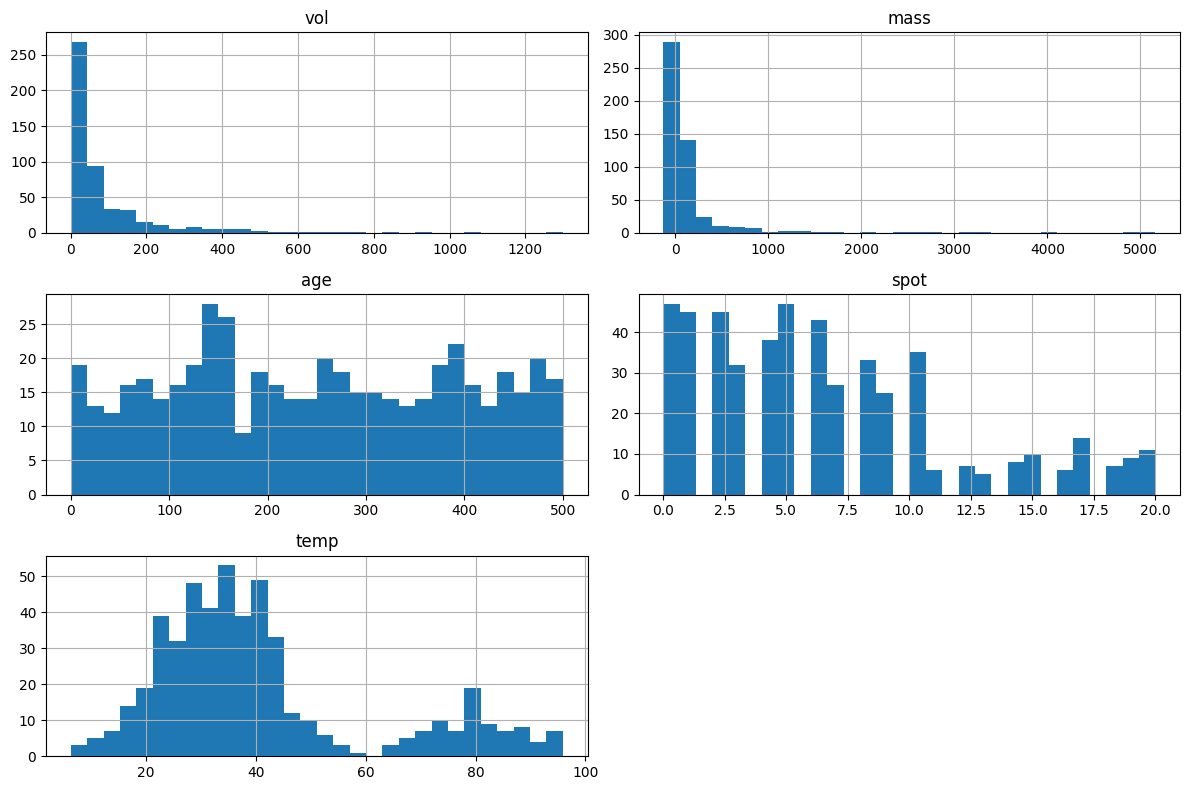

In [15]:
# Building histograms
df = df_main.copy()
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

In [11]:
df_fin.name_contract_type.value_counts()

NameError: name 'df_fin' is not defined

In [ ]:
df_fin[df_fin.name_contract_type == 'Cash loans'].target.value_counts()

,count
target,
0,255011
1,23221


In [ ]:
df_fin[df_fin.name_contract_type == 'Revolving loans'].target.value_counts()

,count
target,
0,27675
1,1604


# **Exploratory Data Analysis**

This method is meant to uncover the underlying structure of a data set and is important for a company because it exposes trends, patterns, and relationships that are not readily apparent.

# **Feature Engineering**

This is a vital step where data is explored and then transformed from raw data into features that enhance machine learning model performance, accuracy, and generalization by making patterns more discernable.

#### Feature Scaling

it prevents features with larger numerical values from disproportionately influencing the model's learning.
When features have vastly different ranges (e.g., one feature ranges from 0-10 and another from 0-10,000), the model can become biased toward the feature with the larger magnitude, simply because its values are larger.

In [ ]:
#df.head()

In [ ]:
# features and target variable
#df_final = df.copy()


# Initialize the scaler
#scaler = RobustScaler()
# apply scaler to predictor variables
#X_scaled = scaler.fit_transform(X)

#### Data Split
Splitting data into training and testing sets is essential to evaluate a model's performance on new, unseen data and prevent overfitting. The training set teaches the model patterns, while the untouched test set provides an unbiased assessment of its generalisation ability, ensuring the model performs accurately in real-world scenarios rather than just on the data it learned from.


In [ ]:
 # Train- test Split: 80% train and 20% test -- random state = 42, ensure the reproducibility of the data split
#X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)

# **Model selection**

A hybrid deep learning architecture was implemented consisting of a stacked autoencoder for unsupervised feature representation learning followed by a feedforward neural network classifier. The autoencoder reduces the high-dimensional feature space into a compact latent embedding, capturing nonlinear interactions among financial variables. The classifier is composed of fully connected layers with ReLU activation, batch normalization, and dropout regularization to prevent overfitting. The model is trained in two stages: (1) unsupervised reconstruction pretraining and (2) supervised fine-tuning for binary classification using binary cross-entropy loss.

1. ****
 :  

 2. **** :

 3. **** :

# **Model Construction**

In this step, data is training data fed to the model. Training a model is essential because it allows the algorithm to learn patterns and relationships from data so it can make accurate predictions or decisions on new, unseen inputs. Without training, the model would have no understanding of how features relate to outcomes.

XGBoost contributes:
handles nonlinearity well
strong on tabular + missing patterns
captures feature interactions explicitly
 Neural Network contributes:
learns dense latent representations
captures smooth nonlinear boundaries
generalizes differently from trees
Stacking layer contributes:
learns optimal combination of both models
reduces overfitting from single model bias
improves calibration of probabilities

# **Model Evaluation**

Models are evaluated using the validation dataset. Validating these trained models is crucial because it helps identify which one performs best to unseen data—without touching the test set. This step acts like a rehearsal before the final performance: it reveals whether the model is overfitting (memorising the training data) or underfitting (failing to learn enough). By evaluating on the validation set, we can select the most promising model and fine-tune its hyperparameters, ensuring that when it is finally tested, the true predictive power is measured — not just luck or overtraining.

# **Interpretation**



In [ ]:
# Evaluation Results
#print(tabulate(results_df, headers='keys', tablefmt='grid'))